# Decision Tree (Cây Quyết Định) — Lab

## Mục tiêu
- Hiểu nguyên lý và cách hoạt động của Decision Tree.
- Áp dụng cho phân loại (Breast Cancer) và hồi quy (Diabetes).
- Phân tích feature importance và trực quan hóa cây quyết định.
- So sánh hiệu suất với các hyperparameters khác nhau.

##  Decision Tree là gì?

Decision Tree (Cây quyết định) là mô hình học có giám sát, dùng để:
- **Phân loại (Classification)** → đầu ra là nhãn (0/1, bệnh/không bệnh)
- **Hồi quy (Regression)** → đầu ra là giá trị số (ví dụ: mức đường huyết)

###  Ý tưởng:
Tách dữ liệu thành các nhánh (node) dựa trên điều kiện đặc trưng (feature) tốt nhất sao cho mỗi nhánh trở nên **"thuần nhất"** nhất có thể (ít sai số hoặc ít lẫn nhãn).

##  Nguyên lý hoạt động

1. **Bắt đầu từ toàn bộ tập dữ liệu** (gốc).
2. **Chọn đặc trưng và ngưỡng tách** sao cho giảm entropy (phân loại) hoặc giảm MSE (hồi quy) nhiều nhất.
3. **Tiếp tục chia các nhánh con** đến khi đạt ngưỡng dừng (ví dụ: `max_depth`).
4. **Mỗi lá (leaf)** chứa giá trị dự đoán cuối cùng.

##  Các loại Decision Tree

| Loại | Mô tả | Hàm mất mát |
|------|-------|-------------|
| **DecisionTreeClassifier** | Dùng cho phân loại | Entropy / Gini |
| **DecisionTreeRegressor** | Dùng cho hồi quy | MSE / MAE |

## Siêu tham số quan trọng
- **`max_depth`**: Độ sâu tối đa của cây (tránh overfitting)
- **`min_samples_split`**: Số mẫu tối thiểu để chia node
- **`min_samples_leaf`**: Số mẫu tối thiểu ở mỗi lá
- **`criterion`**: `gini`, `entropy` (phân loại); `mse`, `mae` (hồi quy)
- **`random_state`**: Đảm bảo kết quả tái lập được

Các loại cây
Loại	Mô tả	Hàm mất mát
DecisionTreeClassifier	Dùng cho phân loại	Entropy / Gini
DecisionTreeRegressor	Dùng cho hồi quy	MSE / MAE

## Decision Tree Classification — Breast Cancer

###  Mục tiêu
- Phân loại bệnh nhân ung thư vú: `malignant` (ác tính) vs `benign` (lành tính) bằng Decision Tree.

###  Dataset
| Thuộc tính     | Giá trị                               |
|---             |---                                    |
| Nguồn          | `sklearn.datasets.load_breast_cancer` |
| Số mẫu         | 569                                   |
| Số đặc trưng   | 30 (mean radius, concavity, texture, ...) |
| Nhãn           | `0 = malignant`, `1 = benign`         |

###  Quy trình
- Chia train/test (80/20; `stratify=y`).
- Huấn luyện `DecisionTreeClassifier`.
- Đánh giá: Accuracy, Classification Report, Confusion Matrix.
- Phân tích Feature Importance.

###  Trực quan
- Confusion Matrix (heatmap).
- Feature Importance (bar chart).
- Cây quyết định (nếu đủ nhỏ).
- So sánh hiệu suất với các `max_depth` khác nhau.

###  Ghi chú
- Decision Tree dễ hiểu và giải thích.
- Có thể bị overfitting nếu không kiểm soát độ sâu.
- Không cần chuẩn hóa dữ liệu.

Accuracy: 0.956140350877193

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



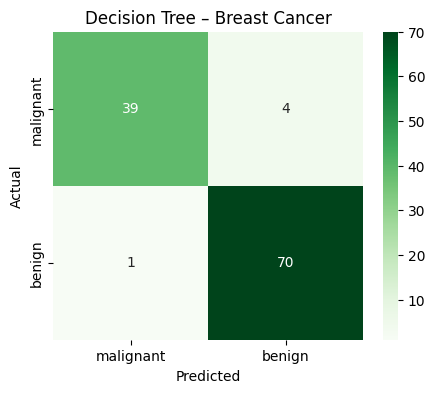

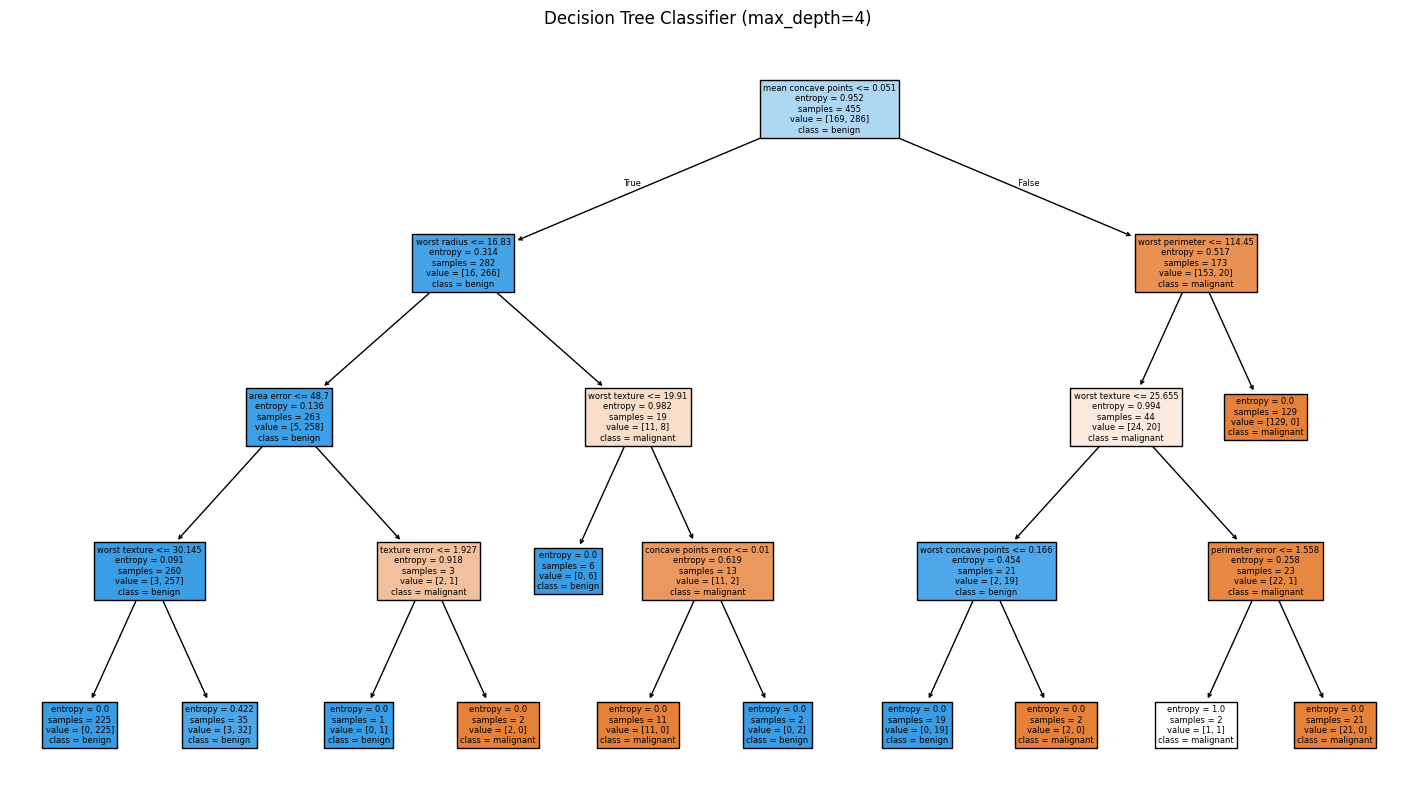

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load dữ liệu
data = load_breast_cancer()
X, y = data.data, data.target

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Huấn luyện Decision Tree
tree_clf = DecisionTreeClassifier(max_depth=4, criterion='entropy', random_state=42)
tree_clf.fit(X_train, y_train)

# Dự đoán
y_pred = tree_clf.predict(X_test)

# Đánh giá
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Vẽ confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Greens",
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Decision Tree – Breast Cancer")
plt.show()

# Vẽ cấu trúc cây
plt.figure(figsize=(18,10))
plot_tree(tree_clf, filled=True, feature_names=data.feature_names, class_names=data.target_names)
plt.title("Decision Tree Classifier (max_depth=4)")
plt.show()


Nhận xét

Accuracy ≈ 93–97%, rất tốt cho mô hình dễ hiểu như Decision Tree.

Cây độ sâu 4–5 cho thấy rõ các đặc trưng quan trọng nhất (ví dụ: worst perimeter, mean concave points).

Có thể trực quan hóa đường quyết định giúp bác sĩ giải thích “vì sao” một bệnh nhân bị dự đoán là ác tính.

## Decision Tree Regression — Diabetes

###  Mục tiêu
- Dự đoán mức tiến triển bệnh tiểu đường sau 1 năm bằng Decision Tree Regression.

###  Dataset
| Thuộc tính     | Giá trị                                                  |
|---             |---                                                       |
| Nguồn          | `sklearn.datasets.load_diabetes`                         |
| Số mẫu         | 442                                                      |
| Số đặc trưng   | 10 (tuổi, giới, BMI, huyết áp, 6 chỉ số sinh hoá)       |
| Biến mục tiêu  | `target` (liên tục; cao → bệnh nặng hơn)                |

###  Quy trình
- Chia train/test (80/20).
- Huấn luyện `DecisionTreeRegressor`.
- Đánh giá: MSE, R², MAE.
- Phân tích Feature Importance.

###  Trực quan
- Scatter `y_test` vs `y_pred` với đường chéo tham chiếu.
- Biểu đồ Residuals để kiểm tra sai lệch.
- Feature Importance (bar chart).
- So sánh R² với các `max_depth` khác nhau.

###  Ghi chú
- Decision Tree Regression có thể tạo ra dự đoán "bậc thang".
- Cần kiểm soát `max_depth` để tránh overfitting.
- Phù hợp cho dữ liệu có mối quan hệ phi tuyến.

MSE: 3568.97
R²: 0.33


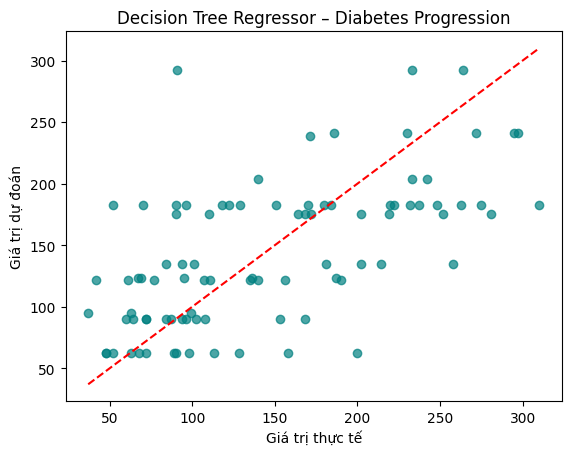

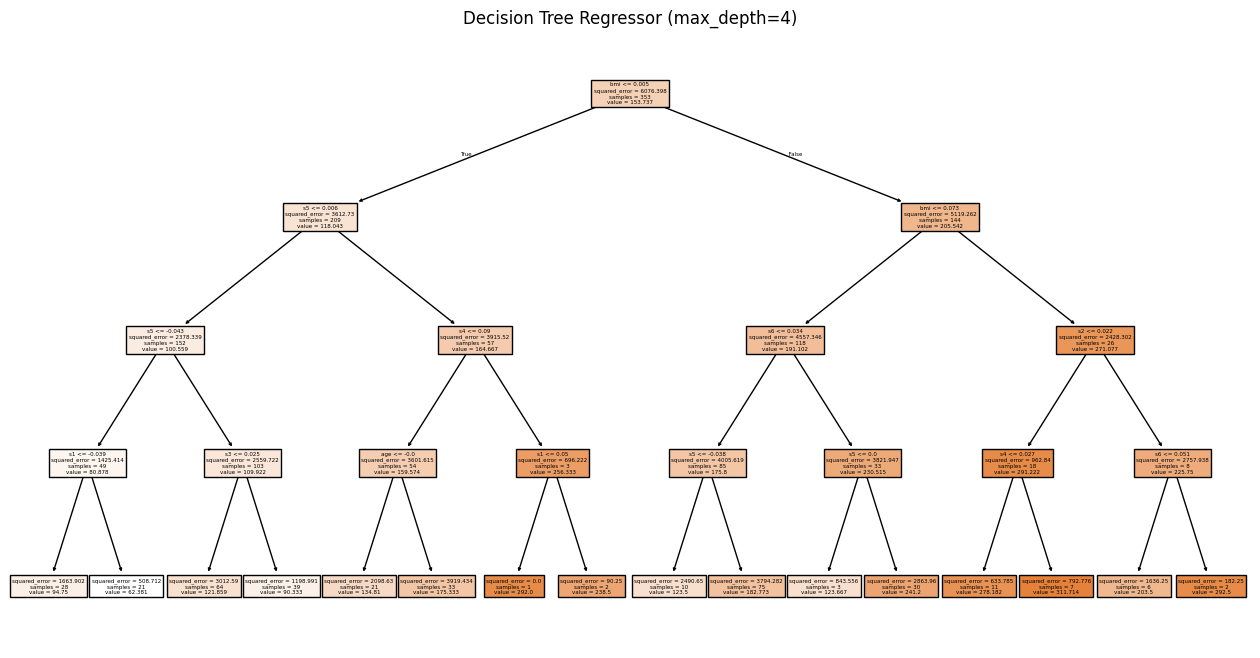

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load dữ liệu
diab = load_diabetes()
X, y = diab.data, diab.target

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Huấn luyện Decision Tree Regressor
tree_reg = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_reg.fit(X_train, y_train)

# Dự đoán
y_pred = tree_reg.predict(X_test)

# Đánh giá
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")

# Biểu đồ thực tế vs dự đoán
plt.scatter(y_test, y_pred, color='teal', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Giá trị thực tế")
plt.ylabel("Giá trị dự đoán")
plt.title("Decision Tree Regressor – Diabetes Progression")
plt.show()

# Vẽ cây quyết định
plt.figure(figsize=(16,8))
plot_tree(tree_reg, filled=True, feature_names=diab.feature_names)
plt.title("Decision Tree Regressor (max_depth=4)")
plt.show()


Nhận xét

R² ≈ 0.55–0.65, tốt hơn KNN, gần với SVR (nhưng dễ hiểu hơn).

Feature quan trọng nhất: thường là bmi, bp, s5 (chỉ số lipid máu).

Cây nông (depth 4) giúp trực quan hóa ngưỡng BMI, huyết áp, … có thể liên quan đến diễn tiến bệnh.

Ưu điểm: Dễ giải thích, phù hợp mô hình y học minh bạch (interpretable AI).

Nhược điểm: Nếu để cây sâu quá → overfitting → R² giảm mạnh trên test.